# Store Sales – Hybrid & Ensemble

Two techniques on top of the pipeline from `03_lightgbm.ipynb` (best so far: global LightGBM, 35 features, LB 0.44810):

1. **Hybrid** — division of labour in *sequence*: a linear model (trend + Fourier seasonality, fitted per series on the log scale) captures the smooth, extrapolatable structure; a LightGBM is then trained on its **residuals** — everything the smooth curve can't explain (paydays, promos, holidays, store quirks). Forecast = linear curve + predicted deviation.
2. **Ensemble** — combination in *parallel*: weighted average of the pure model's and the hybrid's predictions (on the log scale). Helps only where the two make *different* mistakes.

Judged exactly like every previous experiment: the primary holdout (2017-07-31 → 2017-08-15) plus the Aug-2016 seasonal fold, against the pure model's scores.

## 0. Setup & data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

DATA = Path('../data')
PROC = DATA / 'processed'
train = pd.read_pickle(PROC / 'train_features.pkl')
test = pd.read_pickle(PROC / 'test_features.pkl')

VAL_START = pd.Timestamp('2017-07-31')

def rmsle(y_true, y_pred):
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

def apply_dead_rule(pred, df):
    return np.where(df['is_dead_series'] == 1, 0.0, pred)

TARGET = 'sales_log1p'
DROP = ['id', 'date', 'sales', 'sales_log1p']
REJECTED = ['sales_dow4_mean', 'sales_zero_rate_28']          # rejected in modelling §8e
FEATURES = [c for c in train.columns if c not in DROP + REJECTED]   # the winning 35

PARAMS = dict(objective='regression', metric='rmse', learning_rate=0.05,
              num_leaves=127, n_estimators=2000, verbosity=-1, random_state=42)

results = []
print(f'train {train.shape}, test {test.shape}, {len(FEATURES)} features')

train (2715042, 41), test (28512, 39), 35 features


## 1. Stage 1 — linear model: trend + Fourier seasonality

Inputs are **functions of the calendar only** (a time index, weekly dummies, yearly sine/cosine waves) — no past sales enter the prediction, which is what lets it extrapolate calmly past the training boundary. One `LinearRegression` call fits all 1,782 series at once (multi-output: the same design matrix, one coefficient set per series), on the `log1p` scale.

Fitted on the raw `train.csv` (the feature pickle drops pre-opening and early-history rows, but the linear stage wants every observed day).

In [2]:
raw = pd.read_csv(DATA / 'train.csv', parse_dates=['date'],
                  usecols=['date', 'store_nbr', 'family', 'sales'])
raw['date'] = raw['date'].astype('datetime64[ns]')
Ylog = np.log1p(raw.pivot(index='date', columns=['store_nbr', 'family'], values='sales'))
print(f'wide log-sales matrix: {Ylog.shape[0]} days x {Ylog.shape[1]} series')

def make_X(dates):
    """Deterministic calendar design matrix: trend + yearly Fourier + weekly dummies."""
    X = pd.DataFrame(index=dates)
    X['trend'] = (dates - pd.Timestamp('2013-01-01')).days / 365.25
    doy = dates.dayofyear.to_numpy()
    for k in (1, 2, 3, 4):
        X[f'year_sin{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        X[f'year_cos{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    dow = pd.get_dummies(pd.Series(dates.dayofweek, index=dates), prefix='dow',
                         drop_first=True, dtype=float)
    return pd.concat([X, dow], axis=1)

def fit_linear(end_date):
    """Fit the multi-output linear stage on all observed days before end_date."""
    fit_dates = Ylog.index[Ylog.index < end_date]
    return LinearRegression().fit(make_X(fit_dates), Ylog.loc[fit_dates])

def linear_pred_long(lin, dates):
    """Predict log-sales for the given dates, returned long for merging."""
    P = pd.DataFrame(lin.predict(make_X(dates)), index=dates, columns=Ylog.columns)
    return (P.rename_axis('date').stack([0, 1]).rename('linear_log')
            .reset_index())

lin_hold = fit_linear(VAL_START)

wide log-sales matrix: 1684 days x 1782 series


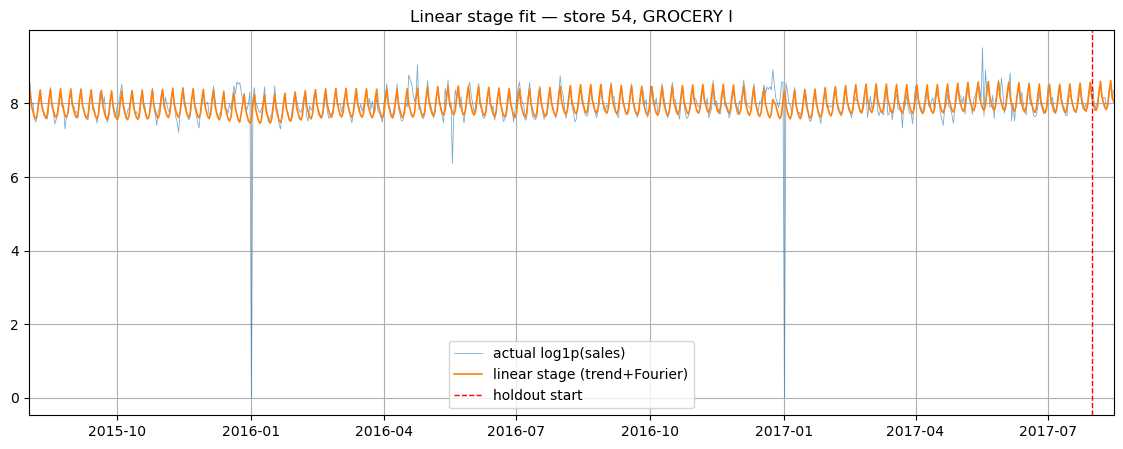

In [3]:
# what the linear stage sees vs misses: one high-volume series, last 2 years
sample = (54, 'GROCERY I') if (54, 'GROCERY I') in Ylog.columns else Ylog.columns[0]
pred_in = pd.Series(lin_hold.predict(make_X(Ylog.index))[:, Ylog.columns.get_loc(sample)],
                    index=Ylog.index)
fig, ax = plt.subplots()
ax.plot(Ylog.index, Ylog[sample], linewidth=0.6, alpha=0.6, label='actual log1p(sales)')
ax.plot(pred_in.index, pred_in.values, linewidth=1.2, label='linear stage (trend+Fourier)')
ax.axvline(VAL_START, color='red', linestyle='--', linewidth=1, label='holdout start')
ax.set_xlim(pd.Timestamp('2015-08-01'), Ylog.index.max())
ax.set_title(f'Linear stage fit — store {sample[0]}, {sample[1]}')
ax.legend()
plt.show()

## 2. Stage 2 — LightGBM on the residuals

New target: `sales_log1p − linear_log` (the deviation from the smooth curve). Same 35 features, same early-stopping discipline. Final prediction = linear curve + predicted deviation, then `expm1` → clip → dead rule.

In [4]:
def add_linear(df, lin):
    dates = pd.DatetimeIndex(df['date'].unique())
    out = df.merge(linear_pred_long(lin, dates), on=['date', 'store_nbr', 'family'],
                   how='left')
    # the merge keys from the wide matrix are str/int -> restore the categorical
    # dtypes LightGBM expects
    out[['store_nbr', 'family']] = out[['store_nbr', 'family']].astype('category')
    assert out['linear_log'].notna().all()
    return out

def fit_hybrid(trn_df, val_df, lin):
    trn_l, val_l = add_linear(trn_df, lin), add_linear(val_df, lin)
    resid_trn = trn_l[TARGET] - trn_l['linear_log']
    resid_val = val_l[TARGET] - val_l['linear_log']
    model = lgb.LGBMRegressor(**PARAMS)
    model.fit(trn_l[FEATURES], resid_trn,
              eval_set=[(val_l[FEATURES], resid_val)],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    return model

def predict_hybrid_log(model, df, lin, n_iter=None):
    df_l = add_linear(df, lin)
    return df_l['linear_log'].to_numpy() + model.predict(df_l[FEATURES], num_iteration=n_iter)

def to_sales(pred_log, df):
    return apply_dead_rule(np.expm1(pred_log).clip(min=0), df)

trn = train[train['date'] < VAL_START]
val = train[train['date'] >= VAL_START]
y_val = val['sales'].to_numpy()

# linear stage alone, as a reference point
lin_only = to_sales(add_linear(val, lin_hold)['linear_log'].to_numpy(), val)
results.append({'model': 'linear stage alone', 'window': 'primary', 'rmsle': rmsle(y_val, lin_only)})

hyb_model = fit_hybrid(trn, val, lin_hold)
hyb_log_val = predict_hybrid_log(hyb_model, val, lin_hold)
score_hyb = rmsle(y_val, to_sales(hyb_log_val, val))
results.append({'model': 'hybrid (linear + GBDT residuals)', 'window': 'primary', 'rmsle': score_hyb})
print(f'linear alone: {results[0]["rmsle"]:.5f}   hybrid: {score_hyb:.5f}   '
      f'(pure LightGBM from 03_lightgbm.ipynb: 0.39847)')

linear alone: 0.92243   hybrid: 0.44030   (pure LightGBM from 03_lightgbm.ipynb: 0.39847)


## 3. The pure model (refit here for self-containment) & the ensemble

Ensemble = weighted average **on the log scale**: `w · pure + (1−w) · hybrid`. The weight is picked on the holdout by grid search — w=1 recovers the pure model, w=0 the hybrid, so the ensemble can never look worse than the better of the two *on the fold it's tuned on*.

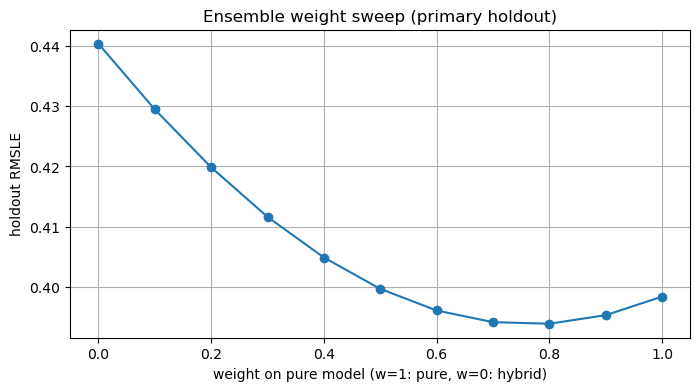

pure 0.39848  hybrid 0.44030  ensemble(w=0.8) 0.39399


In [5]:
pure_model = lgb.LGBMRegressor(**PARAMS)
pure_model.fit(trn[FEATURES], trn[TARGET],
               eval_set=[(val[FEATURES], val[TARGET])],
               callbacks=[lgb.early_stopping(100, verbose=False)])
pure_log_val = pure_model.predict(val[FEATURES])
score_pure = rmsle(y_val, to_sales(pure_log_val, val))
results.append({'model': 'pure LightGBM', 'window': 'primary', 'rmsle': score_pure})

grid = np.round(np.arange(0, 1.01, 0.1), 2)
ens_scores = {w: rmsle(y_val, to_sales(w * pure_log_val + (1 - w) * hyb_log_val, val))
              for w in grid}
w_best = min(ens_scores, key=ens_scores.get)
results.append({'model': f'ensemble (w_pure={w_best})', 'window': 'primary',
                'rmsle': ens_scores[w_best]})

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ens_scores), list(ens_scores.values()), marker='o')
ax.set_xlabel('weight on pure model (w=1: pure, w=0: hybrid)')
ax.set_ylabel('holdout RMSLE')
ax.set_title('Ensemble weight sweep (primary holdout)')
plt.show()
print(f'pure {score_pure:.5f}  hybrid {score_hyb:.5f}  ensemble(w={w_best}) {ens_scores[w_best]:.5f}')

## 4. Confirmation on the Aug-2016 seasonal fold

The trusted leaderboard proxy. Everything refit with data before 2016-08-16 only; the ensemble weight is **carried over** from the holdout (re-tuning it here would overfit the fold).

In [6]:
VS16, VE16 = pd.Timestamp('2016-08-16'), pd.Timestamp('2016-08-31')
trn16 = train[train['date'] < VS16]
val16 = train[(train['date'] >= VS16) & (train['date'] <= VE16)]
y16 = val16['sales'].to_numpy()

lin16 = fit_linear(VS16)
hyb16 = fit_hybrid(trn16, val16, lin16)
hyb_log16 = predict_hybrid_log(hyb16, val16, lin16)

pure16 = lgb.LGBMRegressor(**PARAMS)
pure16.fit(trn16[FEATURES], trn16[TARGET],
           eval_set=[(val16[FEATURES], val16[TARGET])],
           callbacks=[lgb.early_stopping(100, verbose=False)])
pure_log16 = pure16.predict(val16[FEATURES])

for name, plog in [('pure LightGBM', pure_log16), ('hybrid (linear + GBDT residuals)', hyb_log16),
                   (f'ensemble (w_pure={w_best})', w_best * pure_log16 + (1 - w_best) * hyb_log16)]:
    results.append({'model': name, 'window': 'Aug-2016 fold',
                    'rmsle': rmsle(y16, to_sales(plog, val16))})

pd.DataFrame(results).pivot(index='model', columns='window', values='rmsle').round(5)

window,Aug-2016 fold,primary
model,,
ensemble (w_pure=0.8),0.73217,0.39399
hybrid (linear + GBDT residuals),0.73018,0.44030
linear stage alone,NaN,0.92243
pure LightGBM,0.74207,0.39848


## 5. Final retrain & submission

Whichever of {pure, hybrid, ensemble} wins on the primary holdout **without losing on the Aug-2016 fold** gets retrained on all data and written to `submission_hybrid.csv` (kept separate from `03_lightgbm.ipynb`'s `submission.csv`).

In [7]:
res = pd.DataFrame(results)
primary = res[res['window'] == 'primary'].set_index('model')['rmsle']
fold16 = res[res['window'] == 'Aug-2016 fold'].set_index('model')['rmsle']
cands = [m for m in fold16.index if m in primary.index]
# winner: best primary score among candidates that don't lose the seasonal fold to pure
pure_name = 'pure LightGBM'
ok = [m for m in cands if fold16[m] <= fold16[pure_name] + 0.001]
winner = min(ok, key=lambda m: primary[m])
print(f'winner: {winner}  (primary {primary[winner]:.5f}, Aug-2016 {fold16[winner]:.5f})')

n_pure = int(pure_model.best_iteration_ * 1.1)
n_hyb = int(hyb_model.best_iteration_ * 1.1)

def final_pure_log():
    m = lgb.LGBMRegressor(**{**PARAMS, 'n_estimators': n_pure})
    m.fit(train[FEATURES], train[TARGET])
    return m.predict(test[FEATURES])

def final_hybrid_log():
    lin_full = fit_linear(test['date'].max() + pd.Timedelta(days=1))  # all train days
    train_l = add_linear(train, lin_full)
    m = lgb.LGBMRegressor(**{**PARAMS, 'n_estimators': n_hyb})
    m.fit(train_l[FEATURES], train_l[TARGET] - train_l['linear_log'])
    test_l = add_linear(test, lin_full)
    return test_l['linear_log'].to_numpy() + m.predict(test_l[FEATURES])

if winner == pure_name:
    test_log = final_pure_log()
elif winner.startswith('hybrid'):
    test_log = final_hybrid_log()
else:
    test_log = w_best * final_pure_log() + (1 - w_best) * final_hybrid_log()

submission = test[['id']].assign(sales=to_sales(test_log, test)).sort_values('id')
submission.to_csv('submission_hybrid.csv', index=False)
print(f'submission_hybrid.csv: {submission.shape}, sales range '
      f'{submission["sales"].min():.2f} -> {submission["sales"].max():.2f}')

winner: ensemble (w_pure=0.8)  (primary 0.39399, Aug-2016 0.73217)


submission_hybrid.csv: (28512, 2), sales range 0.00 -> 14786.29


## What to look for in the results

- **linear stage alone** will be much worse than everything else — it only knows trend + average seasonality; that's expected and fine, it's a *component*, not a forecaster.
- **hybrid vs pure**: our lag features already carry the recent level, which is most of what the linear stage contributes — so a small or zero gain would not be surprising (the trend-extrapolation advantage matters more on longer horizons than 16 days).
- **ensemble**: watch whether the best weight is interior (0 < w < 1) — that's the signature of the two models making genuinely different mistakes. w stuck at 1.0 means the hybrid adds nothing the pure model lacks.